### main.py через jupyter

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ml_pipeline.config import config
from ml_pipeline.utils import set_seed
from ml_pipeline.pipeline import MLPipeline

In [2]:
set_seed(config.general.seed)

In [3]:
full_df = pd.read_csv(config.paths.train, index_col="PassengerId")
full_test_df = pd.read_csv(config.paths.test, index_col="PassengerId")
full_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
def boxplot(results: list, labels: list | None = None):
    data = []

    for item in results:
        data.append([x["score"] for x in item["fold_data"]])

    plt.boxplot(data, tick_labels=labels)
    plt.show()

In [5]:
pipeline = MLPipeline(config)

In [6]:
pipeline.run(train_df=full_df)

0. dummy
Prepared model with params: {'strategy': 'most_frequent'}
Fold 1/5  accuracy: 0.6145
Prepared model with params: {'strategy': 'most_frequent'}
Fold 2/5  accuracy: 0.6180
Prepared model with params: {'strategy': 'most_frequent'}
Fold 3/5  accuracy: 0.6180
Prepared model with params: {'strategy': 'most_frequent'}
Fold 4/5  accuracy: 0.6180
Prepared model with params: {'strategy': 'most_frequent'}
Fold 5/5  accuracy: 0.6124
-> Best fold: 2, CV accuracy: 0.6162, std: 0.0023

1. logistic_regression
Prepared model with params: {'l1_ratio': 0, 'solver': 'lbfgs', 'max_iter': 500}
Fold 1/5  accuracy: 0.7933
Prepared model with params: {'l1_ratio': 0, 'solver': 'lbfgs', 'max_iter': 500}
Fold 2/5  accuracy: 0.8090
Prepared model with params: {'l1_ratio': 0, 'solver': 'lbfgs', 'max_iter': 500}
Fold 3/5  accuracy: 0.7921
Prepared model with params: {'l1_ratio': 0, 'solver': 'lbfgs', 'max_iter': 500}
Fold 4/5  accuracy: 0.8146
Prepared model with params: {'l1_ratio': 0, 'solver': 'lbfgs', '

In [ ]:
pipeline.predict(test_df=full_test_df)

Best experiment is 4.random_forest with None
Predictions saved to csv


### Логистическая регрессия

Посмотрим, как влияет коэффициент L1 регуляризации на метрику. Видимо, влияние малое

Для параметров ("l1_ratio": 0, "solver": "lbfgs", "max_iter": 500)

- Лучший фолд: 0.8315
- Public LB: 0.76794

In [5]:
config_elastic = config.copy()

to_train = []

for i in range(0, 10):
    to_train.append(
        {
            "model": "logistic_regression",
            "params": {"l1_ratio": i * 0.1, "solver": "saga", "max_iter": 2000},
        }
    )

config_elastic.experiment.to_train = to_train
config_elastic.experiment.prediction.fold_strategy = "vote"

elastic_pipeline = MLPipeline(config_elastic)

elastic_pipeline.run(train_df=full_df)

0. logistic_regression
Prepared model with params: {'l1_ratio': 0.0, 'solver': 'saga', 'max_iter': 2000}
Fold 1/5 accuracy: 0.7933
Prepared model with params: {'l1_ratio': 0.0, 'solver': 'saga', 'max_iter': 2000}
Fold 2/5 accuracy: 0.8090
Prepared model with params: {'l1_ratio': 0.0, 'solver': 'saga', 'max_iter': 2000}
Fold 3/5 accuracy: 0.7921
Prepared model with params: {'l1_ratio': 0.0, 'solver': 'saga', 'max_iter': 2000}
Fold 4/5 accuracy: 0.8146
Prepared model with params: {'l1_ratio': 0.0, 'solver': 'saga', 'max_iter': 2000}
Fold 5/5 accuracy: 0.8258
-> Best fold: 5, CV accuracy: 0.8070, std: 0.0129

1. logistic_regression
Prepared model with params: {'l1_ratio': 0.1, 'solver': 'saga', 'max_iter': 2000}
Fold 1/5 accuracy: 0.7933
Prepared model with params: {'l1_ratio': 0.1, 'solver': 'saga', 'max_iter': 2000}
Fold 2/5 accuracy: 0.8090
Prepared model with params: {'l1_ratio': 0.1, 'solver': 'saga', 'max_iter': 2000}
Fold 3/5 accuracy: 0.7921
Prepared model with params: {'l1_ratio'

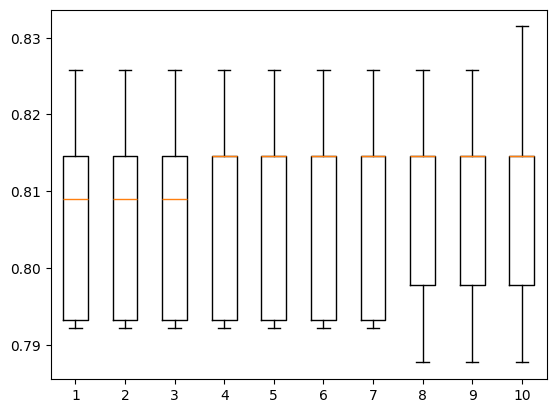

In [6]:
boxplot(elastic_pipeline.results)

In [7]:
elastic_pipeline.predict(full_test_df)

Best step is 9.logistic_regression with {'l1_ratio': 0.9, 'solver': 'saga', 'max_iter': 2000}
Predictions saved to csv


###  KNN

Посмотрим, как меняется метрика в зависимости от количества соседей (k)

По графику вроде бы лучшее кол-во соседей = 7

- Лучший фолд (k=7): 0.8315
- Public LB (k=7): 0.74162

In [ ]:
config_knn = config.copy()

to_train = []

for i in range(1, 10):
    to_train.append(
        {
            "model": "knn",
            "params": {"n_neighbors": i},
        }
    )

config_knn.experiment.to_train = to_train

pipeline_knn = MLPipeline(config_knn)

pipeline_knn.run(train_df=full_df)

0. knn
model_params={'n_neighbors': 1}
Fold 1/5  accuracy: 0.7821
Fold 2/5  accuracy: 0.7303
Fold 3/5  accuracy: 0.6854
Fold 4/5  accuracy: 0.7921
Fold 5/5  accuracy: 0.7640
-> Best fold: 4, CV accuracy: 0.7508, std: 0.0389

1. knn
model_params={'n_neighbors': 2}
Fold 1/5  accuracy: 0.7709
Fold 2/5  accuracy: 0.7247
Fold 3/5  accuracy: 0.7303
Fold 4/5  accuracy: 0.8202
Fold 5/5  accuracy: 0.7303
-> Best fold: 4, CV accuracy: 0.7553, std: 0.0364

2. knn
model_params={'n_neighbors': 3}
Fold 1/5  accuracy: 0.7989
Fold 2/5  accuracy: 0.7697
Fold 3/5  accuracy: 0.6966
Fold 4/5  accuracy: 0.8090
Fold 5/5  accuracy: 0.8090
-> Best fold: 4, CV accuracy: 0.7766, std: 0.0425

3. knn
model_params={'n_neighbors': 4}
Fold 1/5  accuracy: 0.8045
Fold 2/5  accuracy: 0.7978
Fold 3/5  accuracy: 0.7416
Fold 4/5  accuracy: 0.8371
Fold 5/5  accuracy: 0.7921
-> Best fold: 4, CV accuracy: 0.7946, std: 0.0308

4. knn
model_params={'n_neighbors': 5}
Fold 1/5  accuracy: 0.7933
Fold 2/5  accuracy: 0.8202
Fold 3/

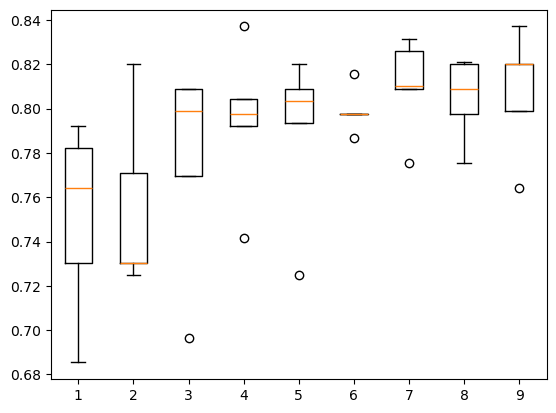

In [ ]:
boxplot(pipeline_knn.results)

### Дерево

Посмотрим, можно ли регуляризовывать дерево минимальным кол-вом объектов в листе

(мин. 4 объекта в листе)
- Лучший фолд: 0.8371
- Public LB: 0.75837

Хуже, чем логрег: Возможно, дерево переобучилось на трейне

In [ ]:
config_tree = config.copy()

to_train = []

for i in range(1, 8):
    to_train.append(
        {
            "model": "decision_tree",
            "params": {"min_samples_leaf": i},
        }
    )

config_tree.experiment.to_train = to_train

pipeline_tree = MLPipeline(config_tree)

pipeline_tree.run(train_df=full_df)

0. decision_tree
model_params={'random_state': 42, 'min_samples_leaf': 1}
Fold 1/5  accuracy: 0.8380
Fold 2/5  accuracy: 0.8034
Fold 3/5  accuracy: 0.7640
Fold 4/5  accuracy: 0.7921
Fold 5/5  accuracy: 0.7865
-> Best fold: 1, CV accuracy: 0.7968, std: 0.0242

1. decision_tree
model_params={'random_state': 42, 'min_samples_leaf': 2}
Fold 1/5  accuracy: 0.8101
Fold 2/5  accuracy: 0.8034
Fold 3/5  accuracy: 0.7865
Fold 4/5  accuracy: 0.8034
Fold 5/5  accuracy: 0.7921
-> Best fold: 1, CV accuracy: 0.7991, std: 0.0085

2. decision_tree
model_params={'random_state': 42, 'min_samples_leaf': 3}
Fold 1/5  accuracy: 0.8156
Fold 2/5  accuracy: 0.7978
Fold 3/5  accuracy: 0.8034
Fold 4/5  accuracy: 0.8202
Fold 5/5  accuracy: 0.7809
-> Best fold: 4, CV accuracy: 0.8036, std: 0.0139

3. decision_tree
model_params={'random_state': 42, 'min_samples_leaf': 4}
Fold 1/5  accuracy: 0.8045
Fold 2/5  accuracy: 0.7978
Fold 3/5  accuracy: 0.8202
Fold 4/5  accuracy: 0.8371
Fold 5/5  accuracy: 0.7978
-> Best fol

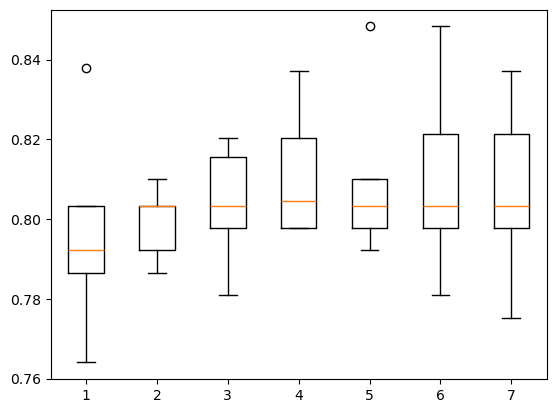

In [ ]:
boxplot(pipeline_tree.results)

### Случайный лес

Посмотрим, зависит ли метрика от кол-ва деревьев

700 деревьев
- Лучший фолд: 0.8371
- Public LB: 0.79186

In [ ]:
config_rf = config.copy()

to_train = []

for i in range(1, 8):
    to_train.append(
        {
            "model": "random_forest",
            "params": {"n_estimators": i * 100},
        }
    )


config_rf.experiment.to_train = to_train

pipeline_rf = MLPipeline(config_rf)

pipeline_rf.run(train_df=full_df)

0. random_forest
model_params={'n_estimators': 100, 'max_depth': 3, 'random_state': 42}
Fold 1/5  accuracy: 0.8101
Fold 2/5  accuracy: 0.8034
Fold 3/5  accuracy: 0.7921
Fold 4/5  accuracy: 0.8202
Fold 5/5  accuracy: 0.8315
-> Best fold: 5, CV accuracy: 0.8114, std: 0.0135

1. random_forest
model_params={'n_estimators': 200, 'max_depth': 3, 'random_state': 42}
Fold 1/5  accuracy: 0.8156
Fold 2/5  accuracy: 0.7978
Fold 3/5  accuracy: 0.8034
Fold 4/5  accuracy: 0.8202
Fold 5/5  accuracy: 0.8371
-> Best fold: 5, CV accuracy: 0.8148, std: 0.0138

2. random_forest
model_params={'n_estimators': 300, 'max_depth': 3, 'random_state': 42}
Fold 1/5  accuracy: 0.7989
Fold 2/5  accuracy: 0.8146
Fold 3/5  accuracy: 0.8034
Fold 4/5  accuracy: 0.8315
Fold 5/5  accuracy: 0.8371
-> Best fold: 5, CV accuracy: 0.8171, std: 0.0150

3. random_forest
model_params={'n_estimators': 400, 'max_depth': 3, 'random_state': 42}
Fold 1/5  accuracy: 0.8045
Fold 2/5  accuracy: 0.8146
Fold 3/5  accuracy: 0.8034
Fold 4/5 

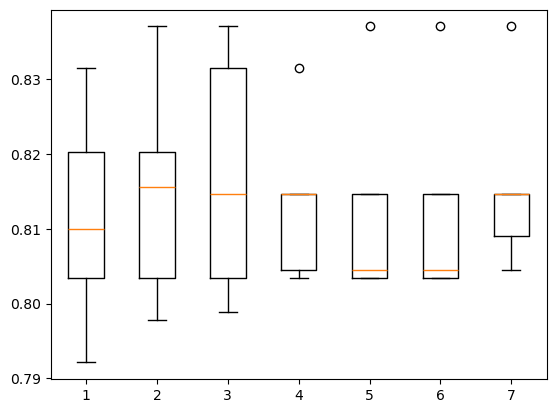

In [ ]:
boxplot(pipeline_rf.results)

### Бустинг

Посмотрим на кол-во итераций: почему-то самая большая метрика получается для 100 деревьев

100 деревьев
- Лучший фолд: 0.8258
- Public LB: 0.78708

1000 деревьев
- Лучший фолд: 0.8268
- Public LB: 0.76315

2000 деревьев
- Лучший фолд: 0.8202
- Public LB: 0.73205

Переобучение? Или при дальнейшем обучении нужно уменьшать learning rate?

In [ ]:
config_cat = config.copy()

to_train = []

iteration_counts = [*[i * 100 for i in range(1, 8)], 1000, 2000]

for ic in iteration_counts:
    to_train.append(
        {
            "model": "catboost",
            "params": {"iterations": ic},
        }
    )


config_cat.experiment.to_train = to_train

pipeline_cat = MLPipeline(config_cat)

pipeline_cat.run(train_df=full_df)

0. catboost
model_params={'iterations': 100, 'depth': 6, 'cat_features': ['Sex', 'Pclass', 'SibSp', 'Parch', 'Alone', 'Age_Group', 'Fare_Range'], 'learning_rate': 0.1, 'random_state': 42, 'verbose': 0}
Fold 1/5  accuracy: 0.8212
Fold 2/5  accuracy: 0.7809
Fold 3/5  accuracy: 0.7865
Fold 4/5  accuracy: 0.8202
Fold 5/5  accuracy: 0.8090
-> Best fold: 1, CV accuracy: 0.8036, std: 0.0169

1. catboost
model_params={'iterations': 200, 'depth': 6, 'cat_features': ['Sex', 'Pclass', 'SibSp', 'Parch', 'Alone', 'Age_Group', 'Fare_Range'], 'learning_rate': 0.1, 'random_state': 42, 'verbose': 0}
Fold 1/5  accuracy: 0.7821
Fold 2/5  accuracy: 0.7978
Fold 3/5  accuracy: 0.7753
Fold 4/5  accuracy: 0.8090
Fold 5/5  accuracy: 0.7809
-> Best fold: 4, CV accuracy: 0.7890, std: 0.0125

2. catboost
model_params={'iterations': 300, 'depth': 6, 'cat_features': ['Sex', 'Pclass', 'SibSp', 'Parch', 'Alone', 'Age_Group', 'Fare_Range'], 'learning_rate': 0.1, 'random_state': 42, 'verbose': 0}
Fold 1/5  accuracy: 0.

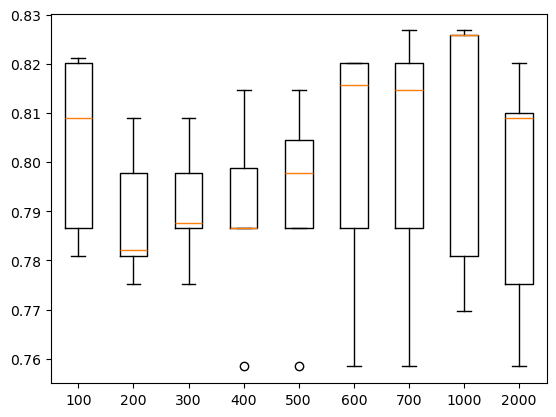

In [ ]:
boxplot(pipeline_cat.results, iteration_counts)

In [ ]:
config_cat = config.copy()

to_train = []

# for i in range(1, 8):
to_train.append(
    {
        "model": "catboost",
        "params": {"iterations": 1000},
    }
)


config_cat.experiment.to_train = to_train

pipeline_cat = MLPipeline(config_cat)

pipeline_cat.run(train_df=full_df)

0. catboost
model_params={'iterations': 1000, 'depth': 6, 'cat_features': ['Sex', 'Pclass', 'SibSp', 'Parch', 'Alone', 'Age_Group', 'Fare_Range'], 'learning_rate': 0.1, 'random_state': 42, 'verbose': 0}
Created model class, starting CV
Fold 0: trying to fit model on data
     Pclass  Sex  SibSp  Parch  Family_Size  Alone  More_Than_4_relatives  \
0         3    0      1      0            1      0                      0   
1         1    1      1      0            1      0                      0   
2         3    1      0      0            0      1                      0   
3         1    1      1      0            1      0                      0   
4         3    0      0      0            0      1                      0   
..      ...  ...    ...    ...          ...    ...                    ...   
707       3    1      0      0            0      1                      0   
708       2    0      0      0            0      1                      0   
709       1    1      0      0     

KeyboardInterrupt: 

In [ ]:
pipeline_cat.predict(test_df=full_test_df)

### LightGBM

Гораздо быстрее, чем CatBoost

Для 300 деревьев:
- Лучший фолд: 0.8258
- Public LB: 0.76794

In [ ]:
config_l = config.copy()

to_train = []

n_estimators = [*[i * 100 for i in range(1, 8)], 1000, 2000]

for n in n_estimators:
    to_train.append(
        {
            "model": "lightgbm",
            "params": {"n_estimators": n},
        }
    )

config_l.experiment.to_train = to_train

config_l.split.n_folds = 2

pipeline_l = MLPipeline(config_l)

pipeline_l.run(train_df=full_df)

0. lightgbm
model_params={'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'random_state': 42, 'verbose': -1}
Fold 1/2  accuracy: 0.8049
Fold 2/2  accuracy: 0.8067
-> Best fold: 2, CV accuracy: 0.8058, std: 0.0009

1. lightgbm
model_params={'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'random_state': 42, 'verbose': -1}
Fold 1/2  accuracy: 0.7870
Fold 2/2  accuracy: 0.8000
-> Best fold: 2, CV accuracy: 0.7935, std: 0.0065

2. lightgbm
model_params={'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'random_state': 42, 'verbose': -1}
Fold 1/2  accuracy: 0.7870
Fold 2/2  accuracy: 0.7865
-> Best fold: 1, CV accuracy: 0.7868, std: 0.0002

3. lightgbm
model_params={'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.1, 'random_state': 42, 'verbose': -1}
Fold 1/2  accuracy: 0.7892
Fold 2/2  accuracy: 0.7910
-> Best fold: 2, CV accuracy: 0.7901, std: 0.0009

4. lightgbm
model_params={'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'random_state':

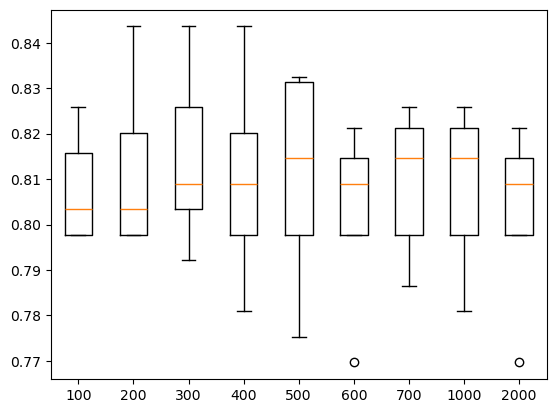

In [ ]:
boxplot(pipeline_l.results, n_estimators)

In [ ]:
pipeline_l.predict(full_test_df)

Best experiment is 2.lightgbm with best_experiment_data.get("params")=None
Predictions saved to csv


### XGBoost

Лучшая метрика для 300 деревьев
- Лучший фолд: 0.8547
- Public LB: 0.77033

In [ ]:
config_xgb = config.copy()

to_train = []

n_estimators = [*[i * 100 for i in range(1, 8)], 1000, 2000]

for n in n_estimators:
    to_train.append(
        {
            "model": "xgboost",
            "params": {"n_estimators": n},
        }
    )

config_xgb.experiment.to_train = to_train

pipeline_xgb = MLPipeline(config_xgb)

pipeline_xgb.run(train_df=full_df)

0. xgboost
model_params={'n_estimators': 100, 'max_depth': 6, 'use_label_encoder': False, 'eval_metric': 'logloss', 'learning_rate': 0.1, 'random_state': 42}
Fold 1/5  accuracy: 0.8492


x:\DSML\Miniconda\envs\titanic\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:55:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
x:\DSML\Miniconda\envs\titanic\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:55:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
x:\DSML\Miniconda\envs\titanic\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:55:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2/5  accuracy: 0.8034
Fold 3/5  accuracy: 0.7978
Fold 4/5  accuracy: 0.8315


x:\DSML\Miniconda\envs\titanic\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:55:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
x:\DSML\Miniconda\envs\titanic\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:55:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
x:\DSML\Miniconda\envs\titanic\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:55:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 5/5  accuracy: 0.7865
-> Best fold: 1, CV accuracy: 0.8137, std: 0.0231

1. xgboost
model_params={'n_estimators': 200, 'max_depth': 6, 'use_label_encoder': False, 'eval_metric': 'logloss', 'learning_rate': 0.1, 'random_state': 42}
Fold 1/5  accuracy: 0.8492


...

Fold 3/5  accuracy: 0.7865


x:\DSML\Miniconda\envs\titanic\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:55:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 4/5  accuracy: 0.8090


x:\DSML\Miniconda\envs\titanic\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:55:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 5/5  accuracy: 0.8034
-> Best fold: 1, CV accuracy: 0.8125, std: 0.0206



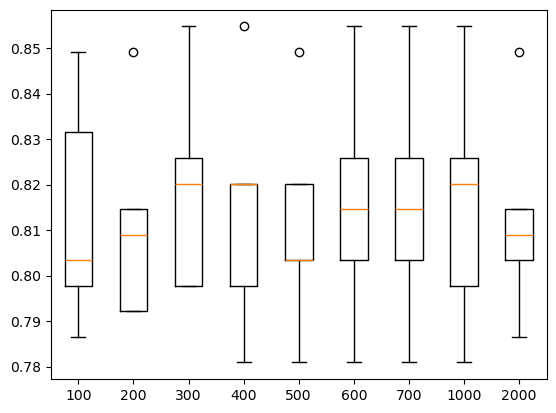

In [ ]:
boxplot(pipeline_xgb.results, n_estimators)

In [ ]:
pipeline_xgb.predict(full_test_df)

Best experiment is 2.xgboost with {'n_estimators': 300}
Predictions saved to csv


### Модели на фичах с openFE

Лучшая метрика
- Лучший фолд:
- Public LB:

In [ ]:
config_dl = config.copy()

config_dl.general.experiment_name = "ensembles_ofe"

config_dl.paths.train = "data/train_openfe.csv"
config_dl.paths.test = "data/test_openfe.csv"

models = ["random_forest", "catboost", "lightgbm", "xgboost"]

for model in models:
    config_dl.models[model].preprocessing = "custom"

config_dl.experiment.to_train = [{"model": x} for x in models]

pipeline_dl = MLPipeline(config_dl)

In [ ]:
ofe_df = pd.read_csv(config_dl.paths.train, index_col="PassengerId")
ofe_test_df = pd.read_csv(config_dl.paths.test, index_col="PassengerId")
ofe_df.head()

,Pclass,Sex,SibSp,Parch,Family_Size,Alone,More_Than_4_relatives,Embarked_C,Embarked_S,Age_Group,...,autoFE_f_292,autoFE_f_293,autoFE_f_294,autoFE_f_295,autoFE_f_296,autoFE_f_297,autoFE_f_298,autoFE_f_299,autoFE_f_300,Survived
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,3,0,1,0,1,0,0,0.0,1.0,2,...,1.0,0.722144,1.0,0.846373,0.837485,359.0,2.0,3.0,0.420000,0
2,1,1,1,0,1,0,0,1.0,0.0,3,...,1.0,0.657895,1.0,0.846373,0.920601,160.0,3.0,2.0,0.883721,1
3,3,1,0,0,0,1,0,0.0,1.0,2,...,1.0,0.333568,0.0,0.361858,0.980687,557.0,2.0,4.0,0.420000,1
4,1,1,1,0,1,0,0,0.0,1.0,3,...,1.0,0.657895,1.0,0.846373,0.051502,359.0,3.0,2.0,0.383721,1
5,3,0,0,0,0,1,0,0.0,1.0,3,...,1.0,0.333568,0.0,0.361858,0.692764,557.0,3.0,3.0,0.383721,0


In [ ]:
pipeline_dl.run(ofe_df)

0. random_forest
Prepared model with params: {'n_estimators': 700, 'max_depth': 3, 'random_state': 42}
Fold 1/5 accuracy: 0.8212
Prepared model with params: {'n_estimators': 700, 'max_depth': 3, 'random_state': 42}
Fold 2/5 accuracy: 0.7978
Prepared model with params: {'n_estimators': 700, 'max_depth': 3, 'random_state': 42}
Fold 3/5 accuracy: 0.8090
Prepared model with params: {'n_estimators': 700, 'max_depth': 3, 'random_state': 42}
Fold 4/5 accuracy: 0.8090
Prepared model with params: {'n_estimators': 700, 'max_depth': 3, 'random_state': 42}
Fold 5/5 accuracy: 0.8371
-> Best fold: 5, CV accuracy: 0.8148, std: 0.0134

1. catboost
Prepared model with params: {'iterations': 300, 'depth': 6, 'cat_features': ['Sex', 'Pclass', 'SibSp', 'Parch', 'Alone', 'Age_Group', 'Fare_Range'], 'learning_rate': 0.1, 'random_state': 42, 'verbose': 0}
Fold 1/5 accuracy: 0.8212
Prepared model with params: {'iterations': 300, 'depth': 6, 'cat_features': ['Sex', 'Pclass', 'SibSp', 'Parch', 'Alone', 'Age_Gro

In [ ]:
config_dl.experiment.prediction.strategy = "each"
config_elastic.experiment.prediction.fold_strategy = "vote"
pipeline_dl.predict(ofe_test_df)

Predicting for each step...
Predictions saved to csv


### Deep Learning

In [7]:
config_dl = config.copy()

config_dl.general.experiment_name = "dnn"
config_dl.split.cv = False

config_dl.experiment.to_train = [{"model": "dnn"}]

pipeline_dl = MLPipeline(config_dl)

In [8]:
pipeline_dl.run(train_df=full_df)

Running (0): dnn with {'in_features': 12, 'epochs': 100, 'batch_size': 16, 'learning_rate': 0.1, 'random_state': 42, 'test_size': 0.2}


Epoch #0/100 ended: mean_train_loss=0.8974, running_train_acc=0.0000, mean_val_loss=0.4185, running_val_acc=0.7958


Epoch #1/100 ended: mean_train_loss=0.5329, running_train_acc=0.0000, mean_val_loss=0.4277, running_val_acc=0.8592


Epoch #2/100 ended: mean_train_loss=0.5239, running_train_acc=0.0000, mean_val_loss=0.4601, running_val_acc=0.7887


epoch 3: saved model with loss 0.4019807196325726
Epoch #3/100 ended: mean_train_loss=0.5104, running_train_acc=0.0000, mean_val_loss=0.4020, running_val_acc=0.8169


...

Epoch #41/100 ended: mean_train_loss=0.4455, running_train_acc=0.0000, mean_val_loss=0.3929, running_val_acc=0.8380


Epoch #42/100 ended: mean_train_loss=0.4378, running_train_acc=0.0000, mean_val_loss=0.3886, running_val_acc=0.8239


Epoch #43/100 ended: mean_train_loss=0.4402, running_train_acc=0.0000, mean_val_loss=0.3929, running_val_acc=0.8380


Epoch #44/100 ended: mean_train_loss=0.4517, running_train_acc=0.0000, mean_val_loss=0.3921, running_val_acc=0.8310
breaking on epoch 44


AttributeError: The following error was raised: 'DNNAdapter' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.